In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import matplotlib.pyplot as plt

from src.env.pricing_env import DynamicPricingEnv
from src.agents.baseline import TimeBasedDiscountAgent

In [2]:
env = DynamicPricingEnv()

agent = TimeBasedDiscountAgent()

state, info = env.reset()

terminated = False

prices = []
revenues = []

while not terminated:

    action = agent.select_action(state)

    state, reward, terminated, truncated, info = env.step(action)

    prices.append(info["price"])
    revenues.append(info["revenue"])

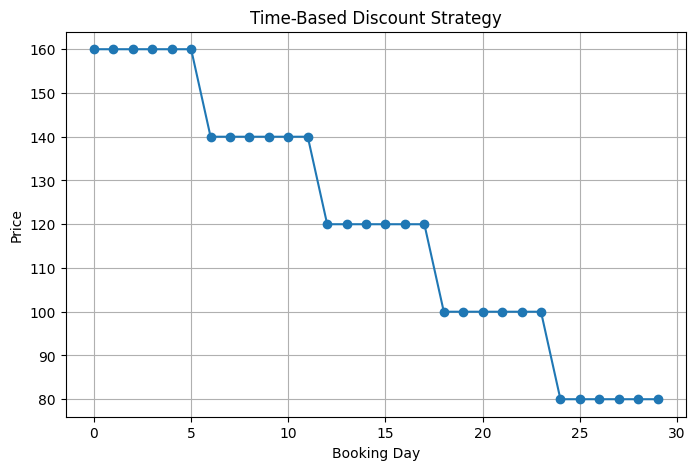

In [3]:
plt.figure(figsize=(8,5))

plt.plot(prices, marker="o")

plt.title("Time-Based Discount Strategy")

plt.xlabel("Booking Day")

plt.ylabel("Price")

plt.grid(True)

plt.show()

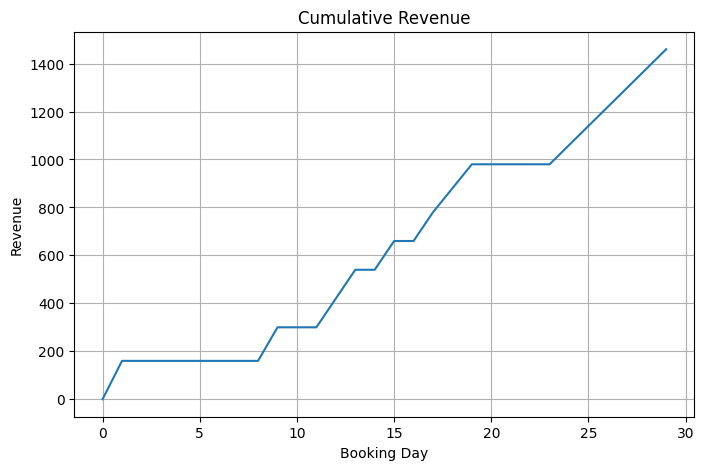

In [4]:
plt.figure(figsize=(8,5))

plt.plot(revenues)

plt.title("Cumulative Revenue")

plt.xlabel("Booking Day")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [5]:
all_revenues = []

for _ in range(100):

    env = DynamicPricingEnv()

    agent = TimeBasedDiscountAgent()

    state, info = env.reset()

    terminated = False

    while not terminated:

        action = agent.select_action(state)

        state, reward, terminated, truncated, info = env.step(action)

    all_revenues.append(env.total_revenue)

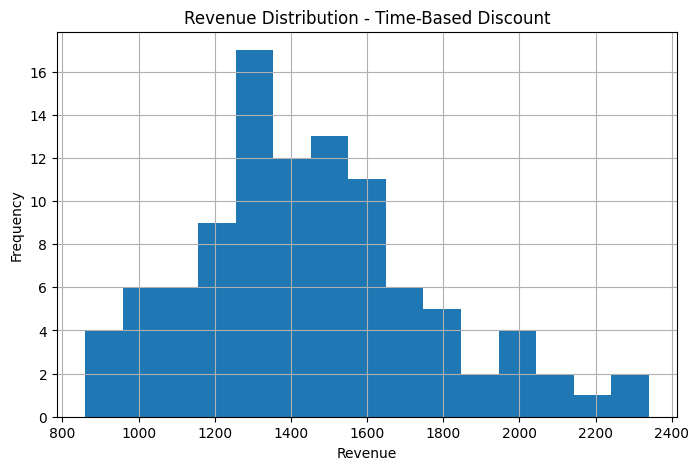

In [6]:
plt.figure(figsize=(8,5))

plt.hist(all_revenues, bins=15)

plt.title("Revenue Distribution - Time-Based Discount")

plt.xlabel("Revenue")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

In [7]:
import numpy as np

print("Average Revenue :", np.mean(all_revenues))
print("Maximum Revenue :", np.max(all_revenues))
print("Minimum Revenue :", np.min(all_revenues))

Average Revenue : 1447.0
Maximum Revenue : 2340
Minimum Revenue : 860
